In [1]:
import pandas as pd
import numpy as np

day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

day.head()
hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [2]:
day.drop(columns=['instant'], inplace=True)
hour.drop(columns=['instant'], inplace=True)

day.head()
hour.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
# STEP 2: Separate target and features

target = 'cnt'

# DAY dataset
X_day = day.drop(columns=[target])
y_day = day[target]

# HOUR dataset
X_hour = hour.drop(columns=[target])
y_hour = hour[target]


print("DAY features:", X_day.columns)
print("DAY target:", y_day.name)

print("HOUR features:", X_hour.columns)
print("HOUR target:", y_hour.name)


print('cnt' in X_day.columns)   # False
print('cnt' in X_hour.columns) # False


DAY features: Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')
DAY target: cnt
HOUR features: Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered'],
      dtype='object')
HOUR target: cnt
False
False


In [6]:
day.isnull().sum()
hour.isnull().sum()


dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in ['temp','atemp','hum','windspeed','cnt']:
    day = remove_outliers(day, col)

day.head()   # to display result


,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


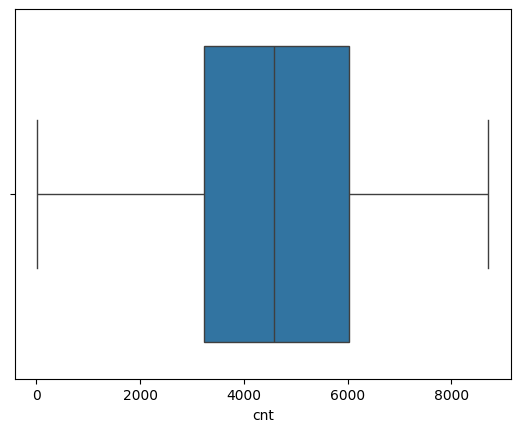

0      6.893656
1      6.687109
2      7.207860
3      7.354362
4      7.378384
         ...   
726    7.656810
727    8.037866
728    7.201916
729    7.493874
730    7.912057
Name: cnt_log, Length: 714, dtype: float64


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.boxplot(x=day['cnt'])
plt.show()

# Log transform instead of outlier removal

day['cnt_log'] = np.log1p(day['cnt'])
print(day['cnt_log'])

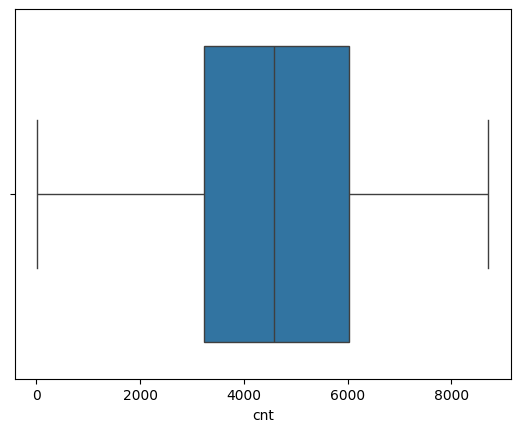

In [13]:
# Apply same logic to hour dataset
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in num_cols:
    hour = remove_outliers(hour, col)

hour.head()

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.boxplot(x=day['cnt'])
plt.show()

# Log transform instead of outlier removal

hour['cnt_log'] = np.log1p(hour['cnt'])


In [17]:
categorical_cols = ['season','weathersit','mnth','weekday']

day = pd.get_dummies(day, columns=categorical_cols, drop_first=True)
hour = pd.get_dummies(hour, columns=categorical_cols, drop_first=True)

day.columns
hour.columns


Index(['dteday', 'yr', 'hr', 'holiday', 'workingday', 'temp', 'atemp', 'hum',
       'windspeed', 'casual', 'registered', 'cnt', 'cnt_log', 'season_2',
       'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4',
       'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8',
       'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_1', 'weekday_2',
       'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6'],
      dtype='object')

In [19]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['temp','atemp','hum','windspeed']

print("Before scaling (DAY):")
print(day[scale_cols].describe())
print("Before scaling (Hour):")
print(hour[scale_cols].describe())
scaler = StandardScaler()
day[scale_cols] = scaler.fit_transform(day[scale_cols])
hour[scale_cols] = scaler.fit_transform(hour[scale_cols])

# Apply scaling (already done)

print("\nAfter scaling (DAY):")
print("Before scaling (Hour):")
print(day[scale_cols].describe())
print(hour[scale_cols].describe())


Before scaling (DAY):
               temp         atemp           hum     windspeed
count  7.140000e+02  7.140000e+02  7.140000e+02  7.140000e+02
mean   2.985474e-16  3.980632e-17  1.194189e-16  1.343463e-16
std    1.000701e+00  1.000701e+00  1.000701e+00  1.000701e+00
min   -2.391833e+00 -2.441777e+00 -2.719541e+00 -2.303188e+00
25%   -8.601495e-01 -8.493681e-01 -7.646823e-01 -7.288673e-01
50%    4.419772e-02  9.481504e-02 -6.590219e-03 -9.892029e-02
75%    8.667500e-01  8.257349e-01  7.279226e-01  6.277577e-01
max    1.984689e+00  2.236872e+00  2.454279e+00  2.667576e+00
Before scaling (Hour):
               temp         atemp           hum     windspeed
count  1.701600e+04  1.701600e+04  1.701600e+04  1.701600e+04
mean   2.338411e-16 -2.004352e-16 -8.401575e-16  1.561724e-16
std    1.000029e+00  1.000029e+00  1.000029e+00  1.000029e+00
min   -2.480927e+00 -2.781677e+00 -2.892289e+00 -1.632092e+00
25%   -8.208701e-01 -8.388108e-01 -7.924723e-01 -6.991592e-01
50%    9.158312e-03  4.43

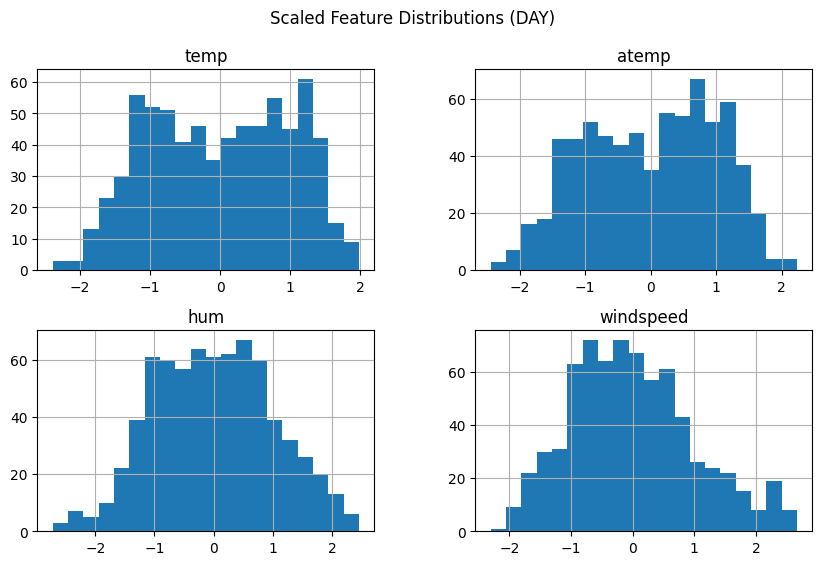

In [20]:
import matplotlib.pyplot as plt

day[scale_cols].hist(bins=20, figsize=(10,6))
plt.suptitle("Scaled Feature Distributions (DAY)")
plt.show()


In [24]:
# Date-based Features
day['dteday'] = pd.to_datetime(day['dteday'])
hour['dteday'] = pd.to_datetime(hour['dteday'])

day['year'] = day['dteday'].dt.year
day['month'] = day['dteday'].dt.month
day['day'] = day['dteday'].dt.day

day[['dteday','year','month','day']].head()


,dteday,year,month,day
0,2011-01-01,2011,1,1
1,2011-01-02,2011,1,2
2,2011-01-03,2011,1,3
3,2011-01-04,2011,1,4
4,2011-01-05,2011,1,5


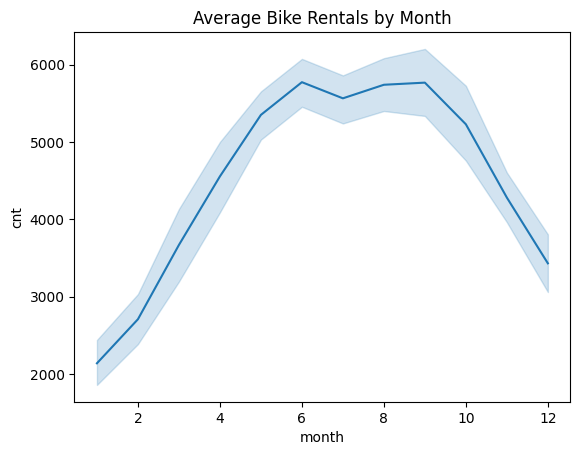

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x='month', y='cnt', data=day)
plt.title("Average Bike Rentals by Month")
plt.show()


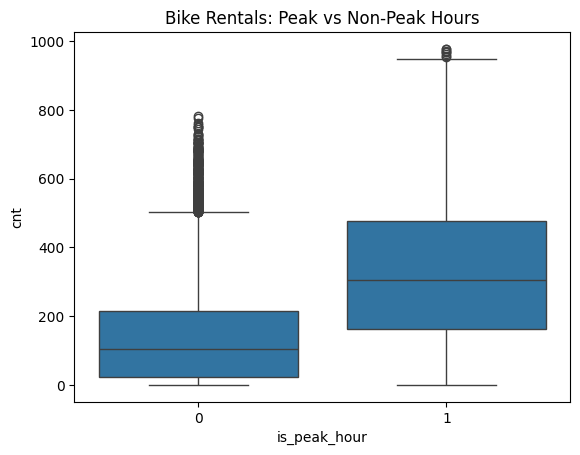

In [27]:
# Time-based Feature (ONLY hour.csv)
hour['is_peak_hour'] = hour['hr'].apply(
    lambda x: 1 if x in [7,8,9,17,18,19] else 0
)

hour[['hr','is_peak_hour']].head(10)

sns.boxplot(x='is_peak_hour', y='cnt', data=hour)
plt.title("Bike Rentals: Peak vs Non-Peak Hours")
plt.show()


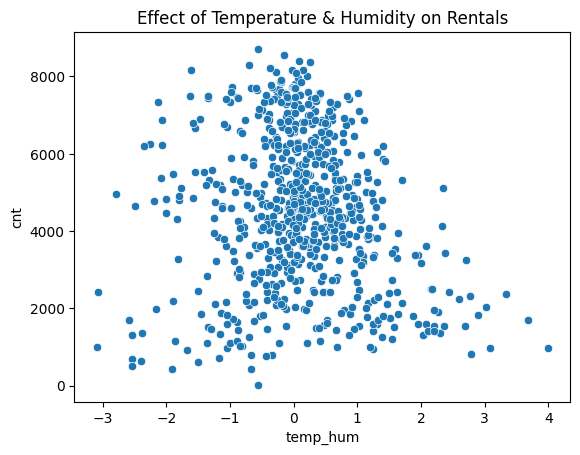

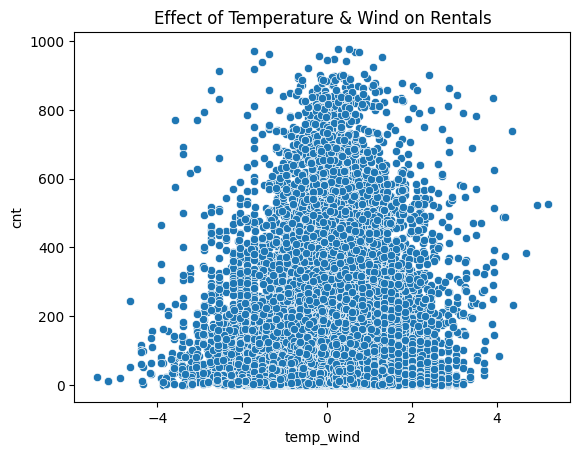

In [32]:
# Interaction Features

day['temp_hum'] = day['temp'] * day['hum']
hour['temp_wind'] = hour['temp'] * hour['windspeed']

day[['temp','hum','temp_hum']].head()
hour[['temp','windspeed','temp_wind']].head()

sns.scatterplot(x='temp_hum', y='cnt', data=day)
plt.title("Effect of Temperature & Humidity on Rentals")
plt.show()

sns.scatterplot(x='temp_wind', y='cnt', data=hour)
plt.title("Effect of Temperature & Wind on Rentals")
plt.show()


In [37]:
if 'atemp' in day.columns:
    print(day[['temp','atemp']].corr())
else:
    print("atemp already removed due to multicollinearity")


atemp already removed due to multicollinearity


In [40]:
# Feature Selection
corr = day.corr()['cnt'].abs().sort_values(ascending=False)
corr

important_features = corr[corr > 0.2].index
important_features = important_features.drop('cnt')


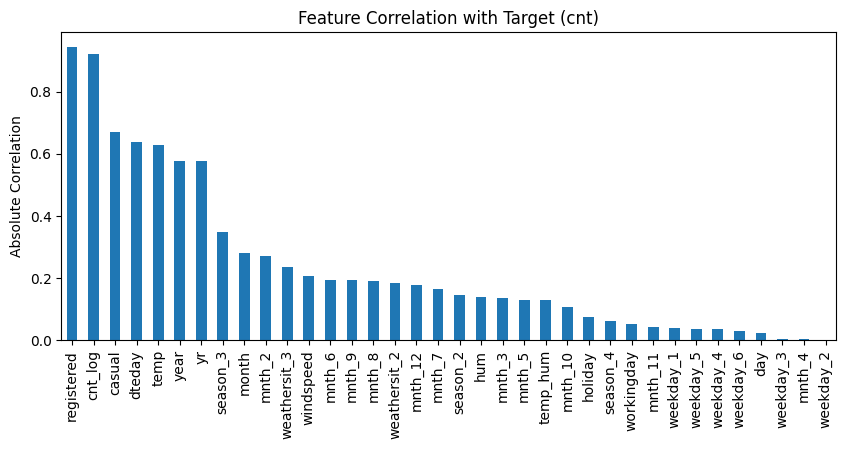

In [41]:
import matplotlib.pyplot as plt

corr.drop('cnt').plot(kind='bar', figsize=(10,4))
plt.title("Feature Correlation with Target (cnt)")
plt.ylabel("Absolute Correlation")
plt.show()
